# Inteligência Artificial Aplicada à Esclerose Múltipla: Preditores de Progressão e Estilo de Vida

## 1. Preparação de Dados e Definição do Alvo (Target)

Total de pacientes no arquivo original: 273
Total de pacientes selecionados para o estudo: 125
Contagem de pacientes que pioraram: 12
Porcentagem de pacientes que pioraram: 9.60%
Contagem de pacientes que ficaram estáveis: 113
Porcentagem de pacientes que ficaram estáveis: 90.40%


C:\Users\laise\AppData\Local\Temp\ipykernel_16632\980437832.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_limpo, x='Houve progressao', palette=['#2ca02c', '#d62728'])
C:\Users\laise\AppData\Local\Temp\ipykernel_16632\980437832.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Estável', 'Piorou'], fontsize=12)


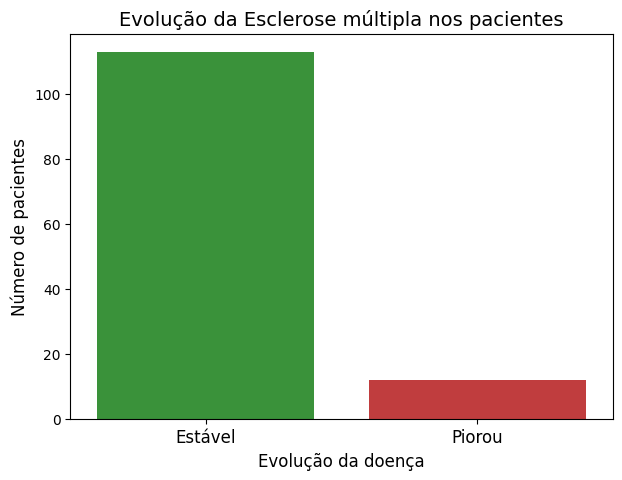

In [2]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Lendo o arquivo
nome_arquivo = 'conversion_predictors_of_clinically_isolated_syndrome_to_multiple_sclerosis.csv'
df = pd.read_csv(nome_arquivo)
print("Total de pacientes no arquivo original: {}".format(df.shape[0]))
# Removendo os pacientes que não possuem o EDSS inicial ou final preenchido
df_limpo = df.dropna(subset=['Initial_EDSS', 'Final_EDSS']).copy()
print("Total de pacientes selecionados para o estudo: {}".format(df_limpo.shape[0]))
# Verificando se a doença progrediu ou não
df_limpo['Houve progressao'] = np.where(df_limpo['Final_EDSS'] > df_limpo['Initial_EDSS'], 1, 0)
# Calculando quantos por cento dos pacientes pioraram e quantos ficaram estáveis
contagem = df_limpo['Houve progressao'].value_counts()
porcentagem = df_limpo['Houve progressao'].value_counts(normalize=True) * 100
print("Contagem de pacientes que pioraram: {}".format(contagem[1]))
print("Porcentagem de pacientes que pioraram: {:.2f}%".format(porcentagem[1]))
print("Contagem de pacientes que ficaram estáveis: {}".format(contagem[0]))
print("Porcentagem de pacientes que ficaram estáveis: {:.2f}%".format(porcentagem[0]))
# Criando um gráfico
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_limpo, x='Houve progressao', palette=['#2ca02c', '#d62728'])
# Trocando o 0 e o 1 por "Estável" e "Piorou"
ax.set_xticklabels(['Estável', 'Piorou'], fontsize=12)
plt.title('Evolução da Esclerose múltipla nos pacientes', fontsize=14)
plt.xlabel('Evolução da doença', fontsize=12)
plt.ylabel('Número de pacientes', fontsize=12)
plt.show()